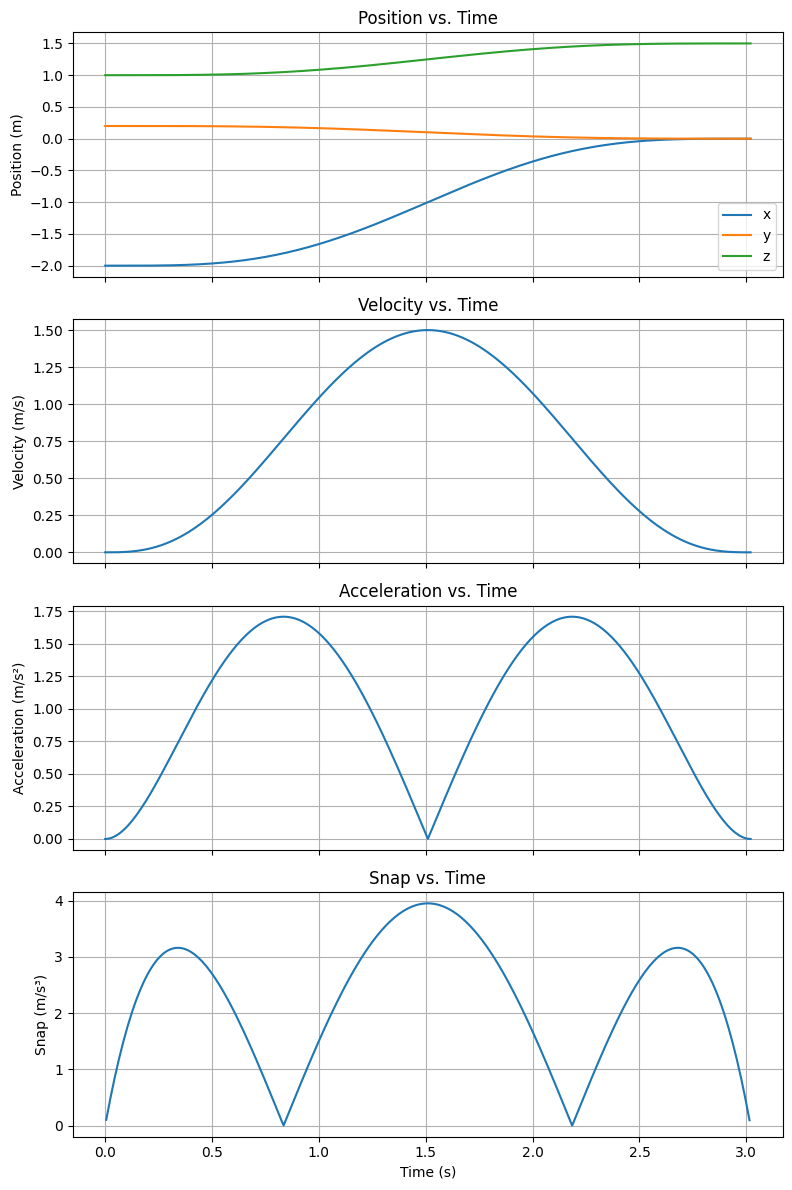

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
from scipy.optimize import minimize

#DERIVED FROM: https://github.com/whoenig/uav_trajectories/blob/main/scripts/generate_trajectory.py
def generate_straight_line_trajectory(
    start,
    end,
    start_vel:   np.ndarray = np.array([0.0, 0.0, 0.0]),
    end_vel:     np.ndarray = np.array([0.0, 0.0, 0.0]),
    max_vel:     float      = 1.5,
    max_acc:     float      = 2.0,
    max_snap:    float      = 10.0,
    dt:          float      = 0.01
) -> np.ndarray:
    """
    Generate a straight-line trajectory from start to end using
    a minimum-snap 7th-order polynomial in the path distance,
    with SciPy optimization to find the minimal feasible duration T.

    Returns:
        traj: (N,13) array [t, px, py, pz, vx, vy, vz, ax, ay, az, jx, jy, jz]
    """
    start = np.asarray(start, float)
    end   = np.asarray(end,   float)
    delta = end - start
    L = np.linalg.norm(delta)
    if L < 1e-8:
        return np.zeros((0,13))

    direction = delta / L
    v0 = np.dot(start_vel, direction)
    v1 = np.dot(end_vel,   direction)

    def poly7_coeffs(T):
        # boundary conditions at t=0
        a0, a1, a2, a3 = 0.0, v0, 0.0, 0.0

        # compute powers of T
        T2 = T * T
        T3 = T2 * T
        T4 = T2 * T2
        T5 = T3 * T2
        T6 = T3 * T3
        T7 = T4 * T3

        # system to solve for a4..a7 at t=T
        A = np.array([
            [   T4,    T5,    T6,     T7],
            [ 4*T3,  5*T4,  6*T5,   7*T6],
            [12*T2, 20*T3, 30*T4,  42*T5],
            [ 24*T,  60*T2,120*T3, 210*T4]
        ])
        b = np.array([
            L - (a0 + a1*T),
            v1 - a1,
            0.0,
            0.0
        ])
        a4, a5, a6, a7 = np.linalg.solve(A, b)
        return np.array([a0, a1, a2, a3, a4, a5, a6, a7])

    # sample profiles for constraint checking
    Ncon = 100
    def sample_profiles(T):
        coeffs = poly7_coeffs(T)[::-1]  # highest→lowest for np.polyval
        t_s = np.linspace(0, T, Ncon)
        s   = np.polyval(coeffs, t_s)
        v   = np.polyval(np.polyder(coeffs, 1), t_s)
        acc = np.polyval(np.polyder(coeffs, 2), t_s)
        j   = np.polyval(np.polyder(coeffs, 3), t_s)
        return v, acc, j

    # constraints: max|v| <= max_vel, etc.
    def c_vel(x):
        v, _, _ = sample_profiles(x[0])
        return max_vel - np.max(np.abs(v))

    def c_acc(x):
        _, acc, _ = sample_profiles(x[0])
        return max_acc - np.max(np.abs(acc))

    def c_snap(x):
        _, _, j = sample_profiles(x[0])
        return max_snap - np.max(np.abs(j))

    cons = [
        {'type': 'ineq', 'fun': c_vel},
        {'type': 'ineq', 'fun': c_acc},
        {'type': 'ineq', 'fun': c_snap},
    ]

    # initial guess for T: distance / max_vel
    T0 = max(L / max_vel, 1e-3)
    res = minimize(lambda x: x[0],
                   x0=[T0],
                   bounds=[(1e-6, None)],
                   constraints=cons,
                   options={'ftol':1e-6})

    if not res.success:
        raise RuntimeError(f"Optimizer failed: {res.message}")

    T_opt = res.x[0]

    # final dense sampling at the user’s dt
    t_arr = np.arange(0, T_opt + dt/2, dt)
    coeffs = poly7_coeffs(T_opt)[::-1]
    s   = np.polyval(coeffs, t_arr)
    v   = np.polyval(np.polyder(coeffs, 1), t_arr)
    acc = np.polyval(np.polyder(coeffs, 2), t_arr)
    j   = np.polyval(np.polyder(coeffs, 3), t_arr)

    traj = np.zeros((len(t_arr), 13))
    traj[:, 0]      = t_arr
    traj[:, 1:4]    = start + np.outer(s,   direction)
    traj[:, 4:7]    = np.outer(v,   direction)
    traj[:, 7:10]   = np.outer(acc, direction)
    traj[:, 10:13]  = np.outer(j,   direction)

    return traj

# Generate trajectory
start = [-2, 0.2, 1]
end   = [0, 0, 1.5]
dt = 0.01
traj = generate_straight_line_trajectory(start, end, dt=dt)

# Extract data
t = traj[:, 0]
pos = traj[:, 1:4]
vel_vec = traj[:, 4:7]
acc_vec = traj[:, 7:10]

vel_mag = np.linalg.norm(vel_vec, axis=1)
acc_mag = np.linalg.norm(acc_vec, axis=1)

# Compute snap (derivative of acceleration)
snap_vec = np.diff(acc_vec, axis=0) / dt
snap_mag = np.linalg.norm(snap_vec, axis=1)
snap_t = t[:-1] + dt/2  # align snap times

# Plot four subplots
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 12))

# Position components
axes[0].plot(t, pos[:, 0], label='x')
axes[0].plot(t, pos[:, 1], label='y')
axes[0].plot(t, pos[:, 2], label='z')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('Position vs. Time')
axes[0].legend()
axes[0].grid(True)

# Velocity magnitude
axes[1].plot(t, vel_mag)
axes[1].set_ylabel('Velocity (m/s)')
axes[1].set_title('Velocity vs. Time')
axes[1].grid(True)

# Acceleration magnitude
axes[2].plot(t, acc_mag)
axes[2].set_ylabel('Acceleration (m/s²)')
axes[2].set_title('Acceleration vs. Time')
axes[2].grid(True)

# Snap magnitude
axes[3].plot(snap_t, snap_mag)
axes[3].set_ylabel('Snap (m/s³)')
axes[3].set_xlabel('Time (s)')
axes[3].set_title('Snap vs. Time')
axes[3].grid(True)

plt.tight_layout()
plt.show()